In [22]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from pathlib import Path
import matplotlib.pyplot as plt
base_path = Path('/content/drive/MyDrive/Dane_solvro_wyzwanie/titanic_preprocessed.csv')

In [38]:
# link do danych titanic_preprocessed
# https://drive.google.com/file/d/17fWAvKP0nPz7ip9IUcFjq0opKe-238-V/view?usp=sharing

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

## Zbiór danych

W zadaniu wykorzystuję przygotowany w zadaniu pierwszym zbiór. Zostały z niego usunięte niepotrzebne kolumny tj. "PassengerID", "Name" oraz " Ticket" - te zmienne nie byłyby przydatne do trenowania modelu, ponieważ można je traktować jako unikalne identyfikatory. Braki danych zostały uzupełnione, tj.
* kolumna Fare - medianą dla odpowiednich kategorii Pclass
* kolumna Age - medianą wieków osób o danych tytułach (z kolumny Name)
* kolumna Embarked - modą
* kolumna Cabin - ze względu na wielką liczbę braków danych została przekształcona w owns_Cabin, zmienną binarną

W przygotowanym zbiorze danych na kolumnach Embarked oraz Age_title zostało zastosowane one-hot-encoding. Kolumna Age_title była wcześniej potrzebna do uzupełniania braków danych w kolumnie Age, jednak na tym etapie wydaje się niepotrzebna (ponieważ posiadamy bardziej szczegółowe informacje - o wieku i płci). Z tego powodu w zbiorze pozostaną tylko kolumny Survived, Pclass, Sex, Age, SibSp, Parch, Fare, owns_Cabin oraz Embarked.

In [24]:
titanic_df = pd.read_csv(base_path)
titanic_df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,owns_Cabin,Embarked_C,Embarked_Q,Embarked_S,Age_title_Master,Age_title_Miss,Age_title_Mr,Age_title_Mrs,Age_title_Other
0,0,1,0,22.0,1,0,7.2500,0,0,0,1,0,0,1,0,0
1,1,3,1,38.0,1,0,71.2833,1,1,0,0,0,0,0,1,0
2,1,1,1,26.0,0,0,7.9250,0,0,0,1,0,1,0,0,0
3,1,3,1,35.0,1,0,53.1000,1,0,0,1,0,0,0,1,0
4,0,1,0,35.0,0,0,8.0500,0,0,0,1,0,0,1,0,0


In [25]:
titanic_df = titanic_df.drop(columns=['Age_title_Master', 'Age_title_Miss', 'Age_title_Mr', 'Age_title_Mrs', 'Age_title_Other'])
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,owns_Cabin,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,22.0,1,0,7.2500,0,0,0,1
1,1,3,1,38.0,1,0,71.2833,1,1,0,0
2,1,1,1,26.0,0,0,7.9250,0,0,0,1
3,1,3,1,35.0,1,0,53.1000,1,0,0,1
4,0,1,0,35.0,0,0,8.0500,0,0,0,1


Ważnym spostrzeżeniem z pierwszego zadania jest fakt, że występuje pewna dysproporcja w danych, tzn. grupa pasażerów, którym nie udało się przetrwać stanowi 61.6% obserwacji, a grupa ocalałych to 38.4%. Dysproporcja nie wydaje się jeszcze na tyle wielka, aby musieć "coś z tym zrobić", jednak warto mieć na uwadze, że wyniki accuracy mogą nie być w pełni miarodajne. Z tego powodu planuję wykorzystać również inne metryki - precision, recall oraz F1.

## Podział danych

In [26]:
X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, shuffle=True, stratify=y, random_state=42
    )

#stratify=y pilnuje żeby proporcja 0 i 1
# w zbiorze treningowym i testowym była taka jak w początkowym zbiorze

## Standaryzacja danych

Standaryzacja danych jest ważnym elementem przygotowania danych. Sprawia ona, że na wszystkie dane można patrzeć w ten sam sposób - jedna kolumna nie będzie ważniejsza od innej tylko ze względu na skalę. Warto ją zastosować dla zmiennych Age oraz Fare, a także SibSp i Parch. Zmienna Pclass nie będzie standaryzowana, ponieważ jest to zmienna kategorialna porządkowa.

Do standaryzacji zmiennych wykorzystam Robust Scaler, ponieważ rozkłady Fare(!), SibSp oraz Parch są prawostronnie skośne oraz występują wartości odstające.
A zmiennej Age to nie zaszkodzi XD

In [27]:
scaler = RobustScaler()
columns_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

## Stworzenie Baseline

In [28]:
model_dummy= DummyClassifier(strategy = 'most_frequent', random_state = 42)
model_dummy.fit(X_train, y_train)
y_pred_dummy = model_dummy.predict(X_test)
print(classification_report(y_test, y_pred_dummy, zero_division=0))
print(confusion_matrix(y_test, y_pred_dummy))

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179

[[110   0]
 [ 69   0]]


Ten model oznaczył 110 rzeczywistych ofiar jako ofiary i 0 jako ocalałych. Z 69 faktycznych ocalałych model oznaczył je jako ofiary i 0 jako ocalałych. Ponieważ model nie przypisał ani razu 1, metryki precision, recall oraz f1-score się wyzerowały. Z kolei accuracy jest na poziomie 61%, co wynika z proporcji klas w danych.
Widać, więc że nawet jak model nic się nie nauczył to ma już 61% accuracy B)

## Wybór modeli

Do badań wybrałam dwa modele uczenia maszynowego: drzewo decyzyjne oraz KNN.
Drzewo decyzyjne samodzielnie szuka cech które najlepiej rozróżniają ofiary od ocalałych, tworząc z nich serię podziałów. W tym przypadku standaryzacja nie była tak potrzebna, jednak w modelu KNN wcześniej przeprowadzona standaryzacja ma znaczenie, ponieważ sprawdzana jest odległość między punktami, które charakteeryzują danego pasażera, a ostateczny wynik predykcji opiera się na przypisaniu najczęściej występującej wśród sąsiadów etykiety (różne skale danych numerycznych mogłyby utrudnić pracę modelowi).

In [29]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred, zero_division=0))
  print(confusion_matrix(y_test, y_pred))


tree = DecisionTreeClassifier(random_state=42) # na razie z max możliwą głębokością
knn = KNeighborsClassifier() # na razie 5 sąsiadów

evaluate_model(tree, X_train, y_train, X_test, y_test)
evaluate_model(knn, X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       110
           1       0.69      0.67      0.68        69

    accuracy                           0.75       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.75      0.75      0.75       179

[[89 21]
 [23 46]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.72      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179

[[91 19]
 [21 48]]


Widać, że nawet przy domyślnych hiperparametrach wyniki dla każdej metryki są lepsze niż dla dummy classifiera. Na ten moment wyniki dla modelu KNN są odrobinę lepsze niż dla drzewa decyzyjnego, jednak zobaczymy jak będzie to wyglądało przy samodzielnym wyborze hiperparametrów. Sprawdzimy też, czy nie ma problemów z overfittingiem.

## Wybór hiperparametrów

W tym przypadku domyślną metryką będzie F1. Jest to spowodowane tym, że accuracy może nie być do końca miarodajne, a F1 jest kompromisem pomiędzy precision i recall.

In [30]:
def plot_validation_curve(model, X, y, param_name, param_range, cv=5, scoring='f1'):
  train_scores, test_scores = validation_curve(
      model, X, y, param_name=param_name, param_range=param_range, cv=cv, scoring=scoring
  )
  train_cv_mean = np.mean(train_scores, axis=1)
  test_cv_mean = np.mean(test_scores, axis=1)


  plt.figure(figsize=(6, 4))
  plt.plot(param_range, train_cv_mean, label="Wynik treningowy", marker='o', color='blue')
  plt.plot(param_range, test_cv_mean, label="Wynik walidacyjny (Cross-Validation)", marker='s', color='orange')

  plt.title(f"Krzywa walidacji dla modelu {model} parametru {param_name}")
  plt.xlabel(f"Wartość parametru: {param_name}")
  plt.ylabel(f"Metryka: {scoring}")
  plt.legend(loc="best")
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.show()

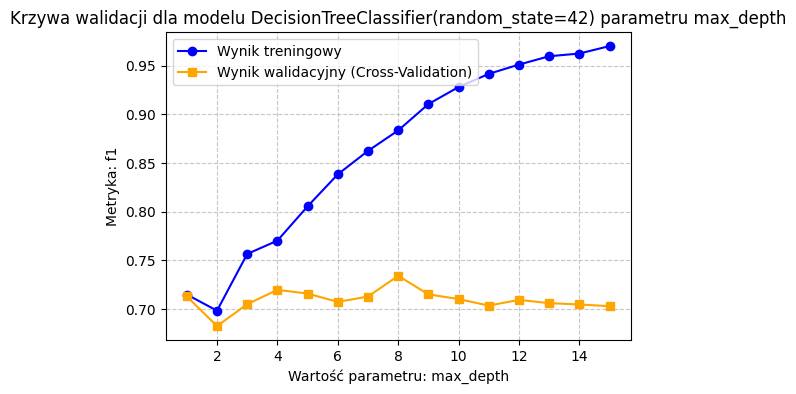

In [31]:
depth = np.arange(1,16)
plot_validation_curve(tree, X_train, y_train, param_name='max_depth', param_range=depth)

Wraz ze wzrostem maksymalnej głębokości drzewa ponad 8 widoczna jest rosnąca skłonność do przeuczenia, model uczy się danych treningowych na pamięć. Z tego powodu rozważane hiperparametry dla max_depth będą pomiędzy 3 a 8.

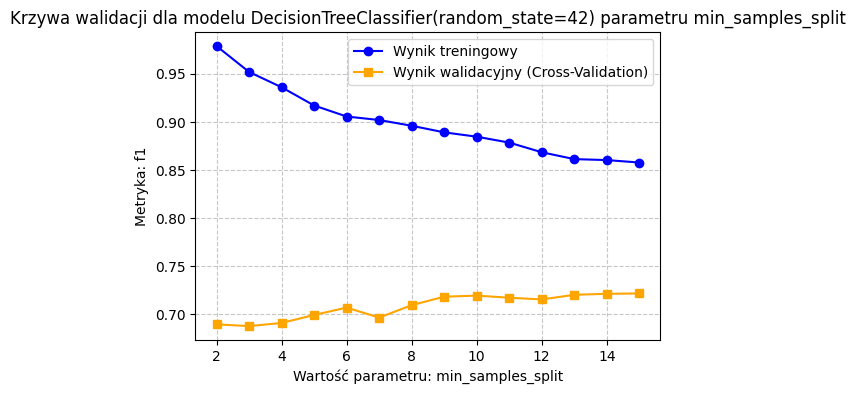

In [32]:
split = np.arange(1,16)
plot_validation_curve(tree, X_train, y_train, param_name='min_samples_split', param_range=split)

Przy najniższych wartościach parametru min_samples_split widać zjawisko overfittingu, natomiast wraz ze zwiększaniem się parametru wyniki dla zbioru treningowego i wyniki walidacyjne zbliżają się do siebie. Dalej sprawdzane wartości tego hiperparametru będą w zakresie od 8 do 15.

In [33]:
grid_tree = {'max_depth': [3,4,5,6,7,8],
              'min_samples_split': [8,9,10,11,12,13,14,15]}

search_tree = GridSearchCV(
  tree,
  grid_tree,
  cv=5,
  scoring='f1'
)

search_tree.fit(X_train, y_train)

print(search_tree.best_params_)
print(search_tree.best_score_)

{'max_depth': 8, 'min_samples_split': 10}
0.7298808635654204


Zatem to będą parametry wybrane do modelu, którego użyję na zbiorze testowym.
Zanim jednak do tego przejdziemy, powtarzam powyższe kroki, aby wybrać odpowiednie hiperparametry dla modelu KNN.

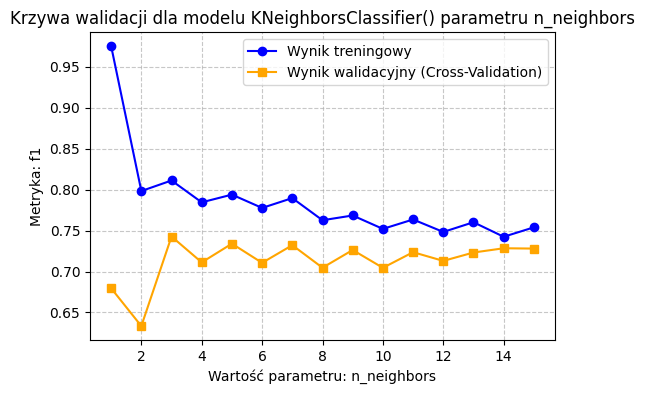

In [34]:
number_of_neighbors = np.arange(1,16)
plot_validation_curve(knn, X_train, y_train, param_name='n_neighbors', param_range=number_of_neighbors)

W przypadku parametru n_neighbors widać, że rozpatrywanie 1 lub 2 sądsiadów prowadziłoby do overfittingu - szczególnie w przypadku n=1 model zapamiętuje dane treningowe, a wynik walidacyjny jest najsłabszy. Najlepszy wynik na zbiorze walidacyjnym jest osiągany dla 3 sąsiadów. Warto też zauważyć, że wyniki walidacyjne dla nieparzystych liczb sąsiadów są lepsze niż dla parzystych.
Ze względu na fakt, że powyżej n=12 wyniki już zbyt się nie różnią (decyzje są uśredniane), dalej rozpatrywane parametry będą w przedziale od 3 do 12.

In [35]:
grid_knn = {'n_neighbors': [3,5,7,9,11],
            'weights': ['uniform', 'distance'],
            'p': [1,2]}

search_knn = GridSearchCV(
  knn,
  grid_knn,
  cv=5,
  scoring='f1'
)

search_knn.fit(X_train, y_train)

print(search_knn.best_params_)
print(search_knn.best_score_)

{'n_neighbors': 9, 'p': 2, 'weights': 'distance'}
0.7534007899664815


Biorąc pod uwagę również pozostałe parametry, okazuje się, że dla 9 sąsiadów w połączeniu z weights = "distance" (bliźsi sąsiedzi są ważniejsi niż ci dalsi) oraz odgległością euklidesową (p=2)otrzymamy najlepsze wyniki.

## Wyniki modeli na zbiorze testowym

In [36]:
evaluate_model(search_tree.best_estimator_, X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       110
           1       0.70      0.64      0.67        69

    accuracy                           0.75       179
   macro avg       0.74      0.73      0.74       179
weighted avg       0.75      0.75      0.75       179

[[91 19]
 [25 44]]


In [37]:
evaluate_model(search_knn.best_estimator_, X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       110
           1       0.70      0.72      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

[[89 21]
 [19 50]]


Metryki dla modelu KNN pozostały odrobinę lepsze niż dla drzewa decyzyjnego. Porównując ostateczne modele z tymi pierwotnymi (z domyślnie ustawionymi parametrami) nie widać większych różnic w metrykach. Warto jednak zwrócić uwagę na to, że teraz modele mogą być bardziej zabezpieczone przed przeuczeniem (szczególnie w przypadku drzewa decyzyjnego).